# Cardiovascular Disease Prediction — Modular ML Pipeline
**Standard Operating Procedure (SOP) Project Milestone**  
Department of Computer Engineering | Academic Year 2025–2026

## 1. Environment Configuration & Library Imports
In this section, we import all necessary numerical, visualization, machine learning, and evaluation libraries.

### 1.1 System & OpenMP Runtime Setup

In [1]:
import os
import sys
import ctypes
import warnings
warnings.filterwarnings('ignore')

# Preload OpenMP runtime for macOS Apple Silicon
for lib_path in [
    '/opt/homebrew/opt/libomp/lib/libomp.dylib',
    '/usr/local/opt/libomp/lib/libomp.dylib',
    '/opt/homebrew/lib/libomp.dylib',
    '/usr/local/lib/libomp.dylib'
]:
    if os.path.exists(lib_path):
        try:
            ctypes.CDLL(lib_path)
            break
        except Exception:
            pass

### 1.2 Core Data Manipulation Libraries

In [2]:
import numpy as np
import pandas as pd
import scipy as sp

### 1.3 Visualization Libraries & Theming

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")

### 1.4 Scikit-Learn Preprocessing & Splitting Modules

In [4]:
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

### 1.5 Evaluation Metrics Modules

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
    auc
)

### 1.6 Machine Learning Classifiers & Ensemble Models

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import joblib

print("✅ All libraries and modules successfully loaded!")

✅ All libraries and modules successfully loaded!


## 2. Dataset Loading & Exploration (Phase 1)
Loading the 70,000 patient cardiovascular disease records and performing structural inspection.

### 2.1 Load Dataset with Dynamic Path Resolution

In [7]:
# Candidate file paths for robust multi-environment loading
csv_candidates = [
    "cardio/cardio_train.csv",
    "../cardio/cardio_train.csv",
    "/Users/cryptorth/Documents/ml/projects/cardio/cardio_train.csv",
    os.path.join(os.getcwd(), 'cardio', 'cardio_train.csv'),
    os.path.join(os.getcwd(), '..', 'cardio', 'cardio_train.csv')
]

data_path = None
for p in csv_candidates:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not locate cardio_train.csv")

df = pd.read_csv(data_path, sep=";")
print(f"Dataset Loaded Successfully from '{data_path}'!")
print(f"Initial Shape: {df.shape[0]:,} rows and {df.shape[1]} columns")

Dataset Loaded Successfully from 'cardio/cardio_train.csv'!
Initial Shape: 70,000 rows and 13 columns


### 2.2 First 5 Records Preview

In [8]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### 2.3 Convert Patient Age from Days to Years

In [9]:
# Transform age (days -> integer years)
df['age'] = (df['age'] / 365.25).round().astype(int)
df[['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cardio']].head()

,age,gender,height,weight,ap_hi,ap_lo,cardio
0,50,2,168,62.0,110,80,0
1,55,1,156,85.0,140,90,1
2,52,1,165,64.0,130,70,1
3,48,2,169,82.0,150,100,1
4,48,1,156,56.0,100,60,0


### 2.4 Dataset Info & Data Types

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


### 2.5 Summary Statistics

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,53.303157,6.760171,30.0,48.00,54.0,58.00,65.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


### 2.6 Missing Value Analysis

In [12]:
missing_vals = df.isnull().sum()
print("Missing values count per feature:")
print(missing_vals)

Missing values count per feature:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


## 3. Exploratory Data Analysis (EDA)
Visualizing class balance, continuous distributions, categorical correlations, and multi-collinearity.

### 3.1 Target Variable Distribution (`cardio`)

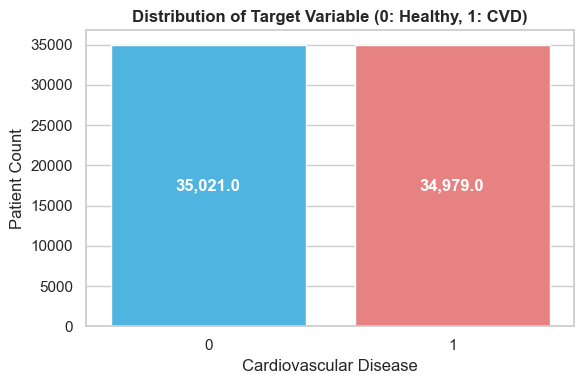

In [13]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='cardio', data=df, palette=['#38bdf8', '#f87171'])
plt.title('Distribution of Target Variable (0: Healthy, 1: CVD)', fontsize=12, fontweight='bold')
plt.xlabel('Cardiovascular Disease')
plt.ylabel('Patient Count')

# Annotate counts
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 Continuous Features Distribution

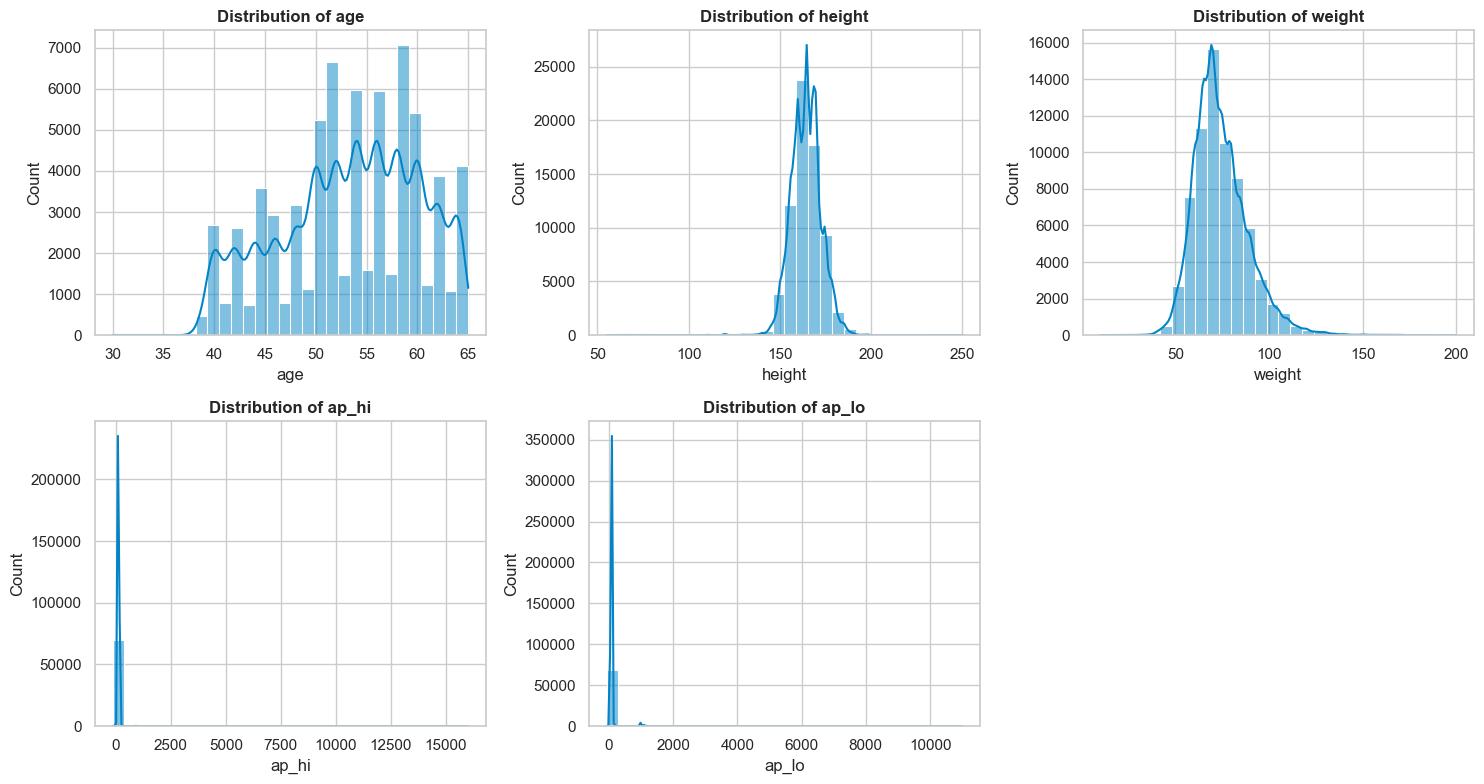

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
continuous_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for idx, col in enumerate(continuous_cols):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='#0284c7', bins=30)
    ax.set_title(f'Distribution of {col}', fontweight='bold')

axes[1, 2].set_visible(False) # Hide extra subplot
plt.tight_layout()
plt.show()

### 3.3 Categorical Features vs CVD Target

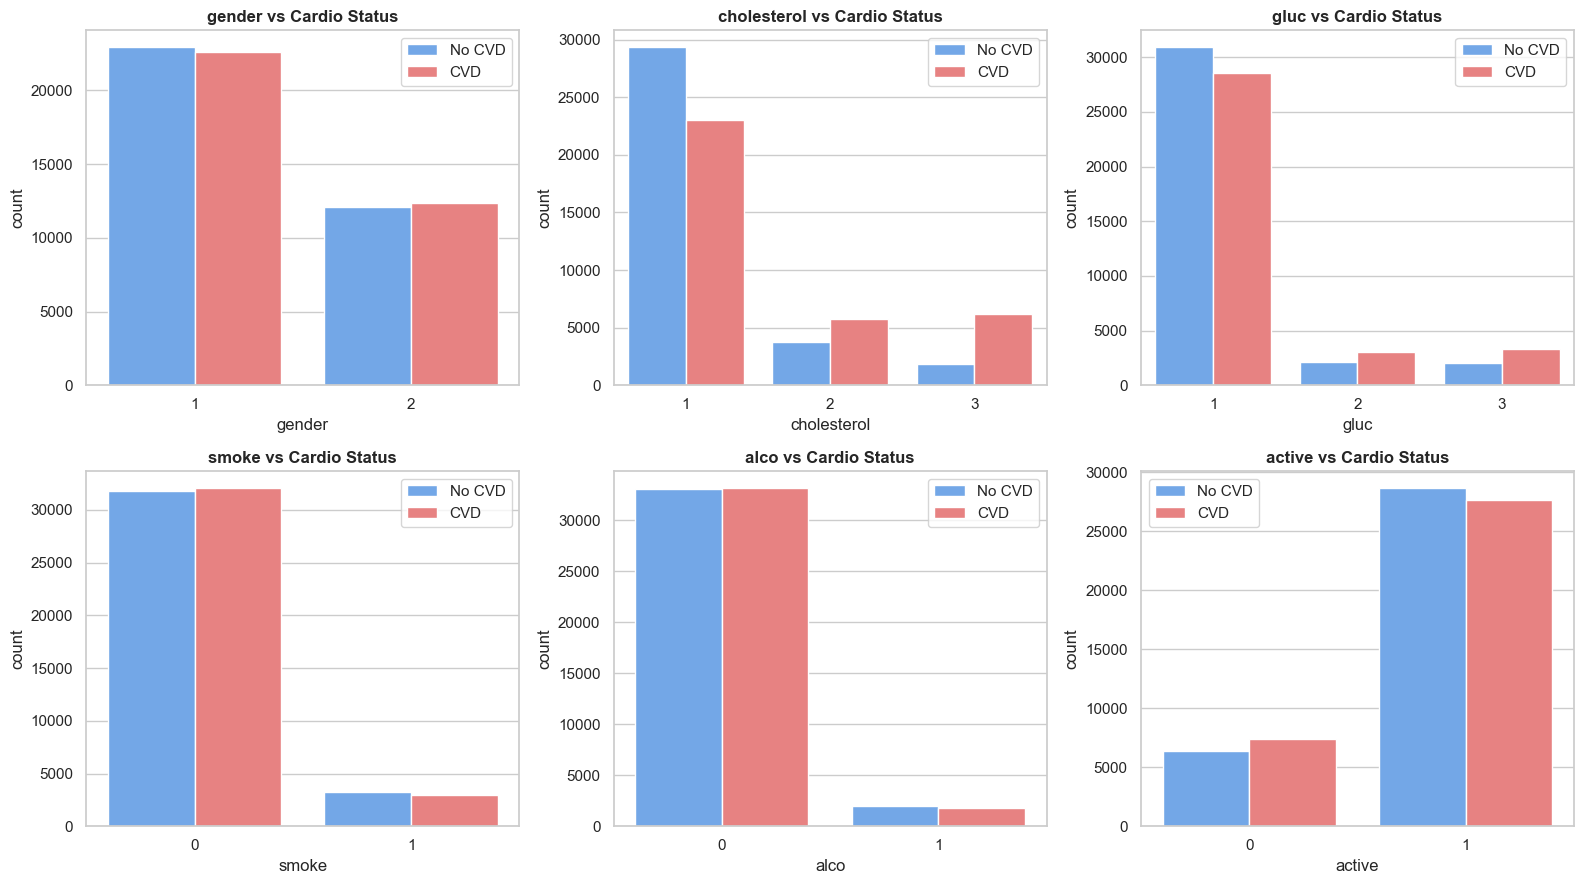

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for idx, col in enumerate(cat_cols):
    ax = axes[idx // 3, idx % 3]
    sns.countplot(x=col, hue='cardio', data=df, ax=ax, palette=['#60a5fa', '#f87171'])
    ax.set_title(f'{col} vs Cardio Status', fontweight='bold')
    ax.legend(['No CVD', 'CVD'])

plt.tight_layout()
plt.show()

### 3.4 Feature Correlation Heatmap

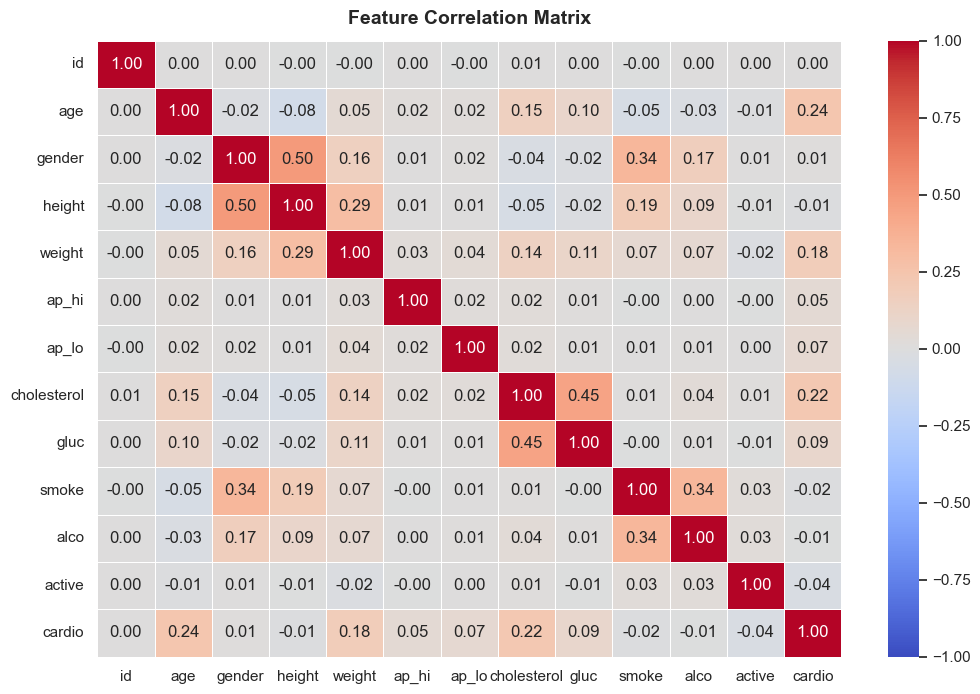

In [16]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.show()

### 3.5 Clinical Age & Weight Distribution Boxplots

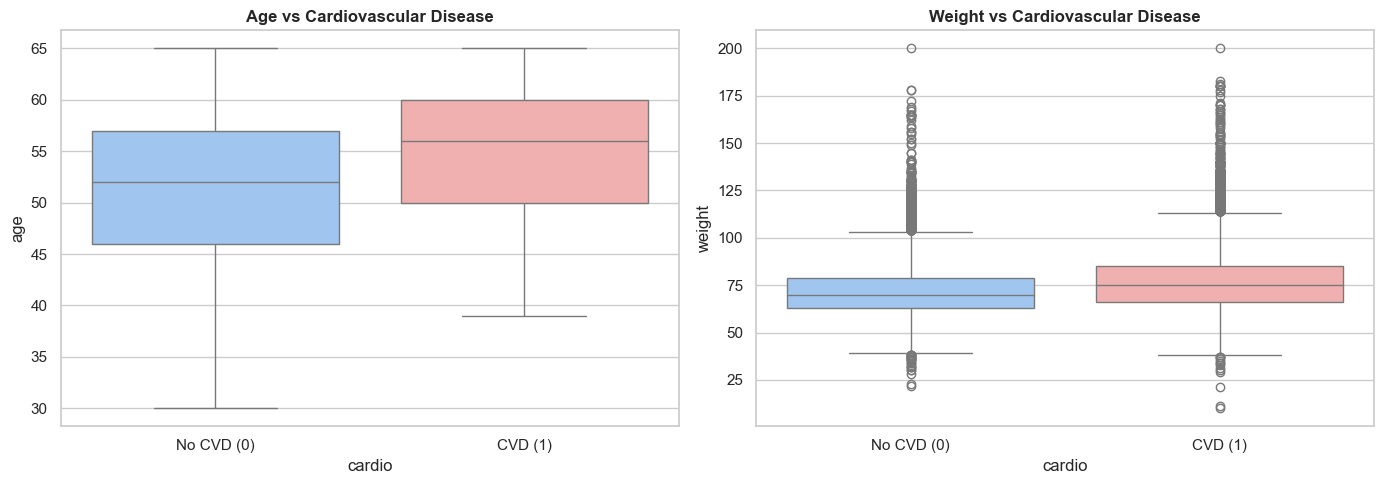

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='cardio', y='age', data=df, ax=axes[0], palette=['#93c5fd', '#fca5a5'])
axes[0].set_title('Age vs Cardiovascular Disease', fontweight='bold')
axes[0].set_xticklabels(['No CVD (0)', 'CVD (1)'])

sns.boxplot(x='cardio', y='weight', data=df, ax=axes[1], palette=['#93c5fd', '#fca5a5'])
axes[1].set_title('Weight vs Cardiovascular Disease', fontweight='bold')
axes[1].set_xticklabels(['No CVD (0)', 'CVD (1)'])

plt.tight_layout()
plt.show()

## 4. Data Pre-processing & Feature Engineering (Phase 2)
Filtering physiological anomalies and computing clinical risk indicators (**BMI** and **Pulse Pressure**).

### 4.1 Remove Duplicate Records

In [18]:
initial_len = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {initial_len - len(df)}")

Duplicates removed: 0


### 4.2 Physiological Outlier Removal

In [19]:
# Physiological thresholds based on medical guidelines
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 240)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 140)]
df = df[df['ap_lo'] < df['ap_hi']]
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

print(f"Cleaned dataset samples: {len(df):,} (Filtered {initial_len - len(df):,} invalid rows)")

Cleaned dataset samples: 68,632 (Filtered 1,368 invalid rows)


### 4.3 Feature Engineering: Body Mass Index (BMI)

In [20]:
# BMI = weight (kg) / (height (m))^2
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
print("BMI summary:")
print(df['bmi'].describe())

BMI summary:
count    68632.000000
mean        27.473219
std          5.351512
min         10.726644
25%         23.875115
50%         26.346494
75%         30.119376
max        152.551775
Name: bmi, dtype: float64


### 4.4 Feature Engineering: Pulse Pressure (PP)

In [21]:
# Pulse Pressure = Systolic BP - Diastolic BP
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
print("Pulse Pressure summary:")
print(df['pulse_pressure'].describe())

Pulse Pressure summary:
count    68632.000000
mean        45.369274
std         11.665873
min          5.000000
25%         40.000000
50%         40.000000
75%         50.000000
max        140.000000
Name: pulse_pressure, dtype: float64


### 4.5 Train / Test Stratified Split (80% Train, 20% Test)

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(['id', 'cardio'], axis=1)
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Testing set:  {X_test.shape[0]:,} samples")

Training set: 54,905 samples
Testing set:  13,727 samples


### 4.6 Feature Standardization (ColumnTransformer)

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

continuous_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure']
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', categorical_features)
    ]
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
feature_names = continuous_features + categorical_features

print("StandardScaler applied to continuous features successfully!")

StandardScaler applied to continuous features successfully!


## 5. Scratch Implementation (SOP Mandatory Requirement - Phase 3)
Implementing Logistic Regression and Gradient Descent from scratch without using scikit-learn.

### 5.1 Scratch Logistic Regression Model Definition

In [24]:
def logistic_regression_scratch(X, y, lr=0.1, iterations=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0.0

    for i in range(iterations):
        linear = np.dot(X, weights) + bias
        # Sigmoid with numerical clipping to prevent overflow
        y_hat = 1 / (1 + np.exp(-np.clip(linear, -250, 250)))
        
        # Gradients
        dw = (1 / m) * np.dot(X.T, (y_hat - y))
        db = (1 / m) * np.sum(y_hat - y)
        
        # Gradient descent update
        weights -= lr * dw
        bias -= lr * db

    return weights, bias

### 5.2 Scratch Prediction & Probability Functions

In [25]:
def predict_proba_scratch(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return 1 / (1 + np.exp(-np.clip(linear, -250, 250)))

def predict_scratch(X, weights, bias, threshold=0.5):
    probs = predict_proba_scratch(X, weights, bias)
    return (probs >= threshold).astype(int)

### 5.3 Train Scratch Logistic Regression

In [26]:
print("Training Scratch Logistic Regression (1000 iterations, learning_rate=0.1)...")
w_scratch, b_scratch = logistic_regression_scratch(
    X_train_scaled, y_train.to_numpy(), lr=0.1, iterations=1000
)

scratch_train_preds = predict_scratch(X_train_scaled, w_scratch, b_scratch)
scratch_test_preds = predict_scratch(X_test_scaled, w_scratch, b_scratch)
scratch_test_probs = predict_proba_scratch(X_test_scaled, w_scratch, b_scratch)
print("✅ Scratch Model Training Complete!")

Training Scratch Logistic Regression (1000 iterations, learning_rate=0.1)...


✅ Scratch Model Training Complete!


### 5.4 Evaluate Scratch Model Test Performance

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("=== Scratch Logistic Regression Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, scratch_test_preds):.4f}")
print(f"Precision: {precision_score(y_test, scratch_test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, scratch_test_preds):.4f}")
print(f"F1-Score:  {f1_score(y_test, scratch_test_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, scratch_test_probs):.4f}")

=== Scratch Logistic Regression Performance ===
Accuracy:  0.7275
Precision: 0.7512
Recall:    0.6718
F1-Score:  0.7093
ROC-AUC:   0.7953


## 6. Baseline Models Evaluation (Week 4 SOP Milestone)
Comparing the scratch implementation against library-based models on the hold-out test set.

### 6.1 Initialize Baseline Models Dictionary

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

baseline_models = {
    'Scratch Logistic Reg': None,
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=9, n_jobs=-1),
    'Naive Bayes (Gaussian)': GaussianNB(),
    'XGBoost': XGBClassifier(eval_metric='logloss', max_depth=5, learning_rate=0.08, n_estimators=120, random_state=42, n_jobs=-1)
}

### 6.2 Train & Evaluate Baseline Models

In [29]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

week4_results = []
y_probs_dict = {}
y_preds_dict = {}

for name, model in baseline_models.items():
    if name == 'Scratch Logistic Reg':
        train_preds = scratch_train_preds
        test_preds = scratch_test_preds
        test_probs = scratch_test_probs
    else:
        model.fit(X_train_scaled, y_train)
        train_preds = model.predict(X_train_scaled)
        test_preds = model.predict(X_test_scaled)
        test_probs = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else test_preds

    y_probs_dict[name] = test_probs
    y_preds_dict[name] = test_preds

    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)
    prec = precision_score(y_test, test_preds)
    rec = recall_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds)
    roc_auc = roc_auc_score(y_test, test_probs)
    tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
    spec = tn / (tn + fp)
    overfit_gap = (train_acc - test_acc) * 100

    week4_results.append({
        'Model': name,
        'Train Acc (%)': round(train_acc * 100, 2),
        'Test Acc (%)': round(test_acc * 100, 2),
        'Overfit Gap (%)': round(overfit_gap, 2),
        'Precision': round(prec, 4),
        'Recall (Sens)': round(rec, 4),
        'Specificity': round(spec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

### 6.3 Baseline Performance Benchmark Table

In [30]:
week4_df = pd.DataFrame(week4_results).sort_values(by='F1-Score', ascending=False)
display(week4_df)

,Model,Train Acc (%),Test Acc (%),Overfit Gap (%),Precision,Recall (Sens),Specificity,F1-Score,ROC-AUC
6,XGBoost,74.44,73.56,0.89,0.7519,0.6947,0.7755,0.7222,0.8026
2,Decision Tree,74.09,73.09,1.00,0.7469,0.6897,0.7712,0.7172,0.7910
3,Random Forest,75.28,73.40,1.89,0.7621,0.6721,0.7946,0.7142,0.8023
0,Scratch Logistic Reg,72.74,72.75,-0.02,0.7512,0.6718,0.7822,0.7093,0.7953
1,Logistic Regression,72.75,72.71,0.03,0.7511,0.6706,0.7824,0.7086,0.7954
4,K-Nearest Neighbors,76.17,71.42,4.75,0.7194,0.6924,0.7356,0.7056,0.7688
5,Naive Bayes (Gaussian),71.47,71.19,0.29,0.7601,0.6102,0.8114,0.6770,0.7823


### 6.4 Confusion Matrices of Baseline Models

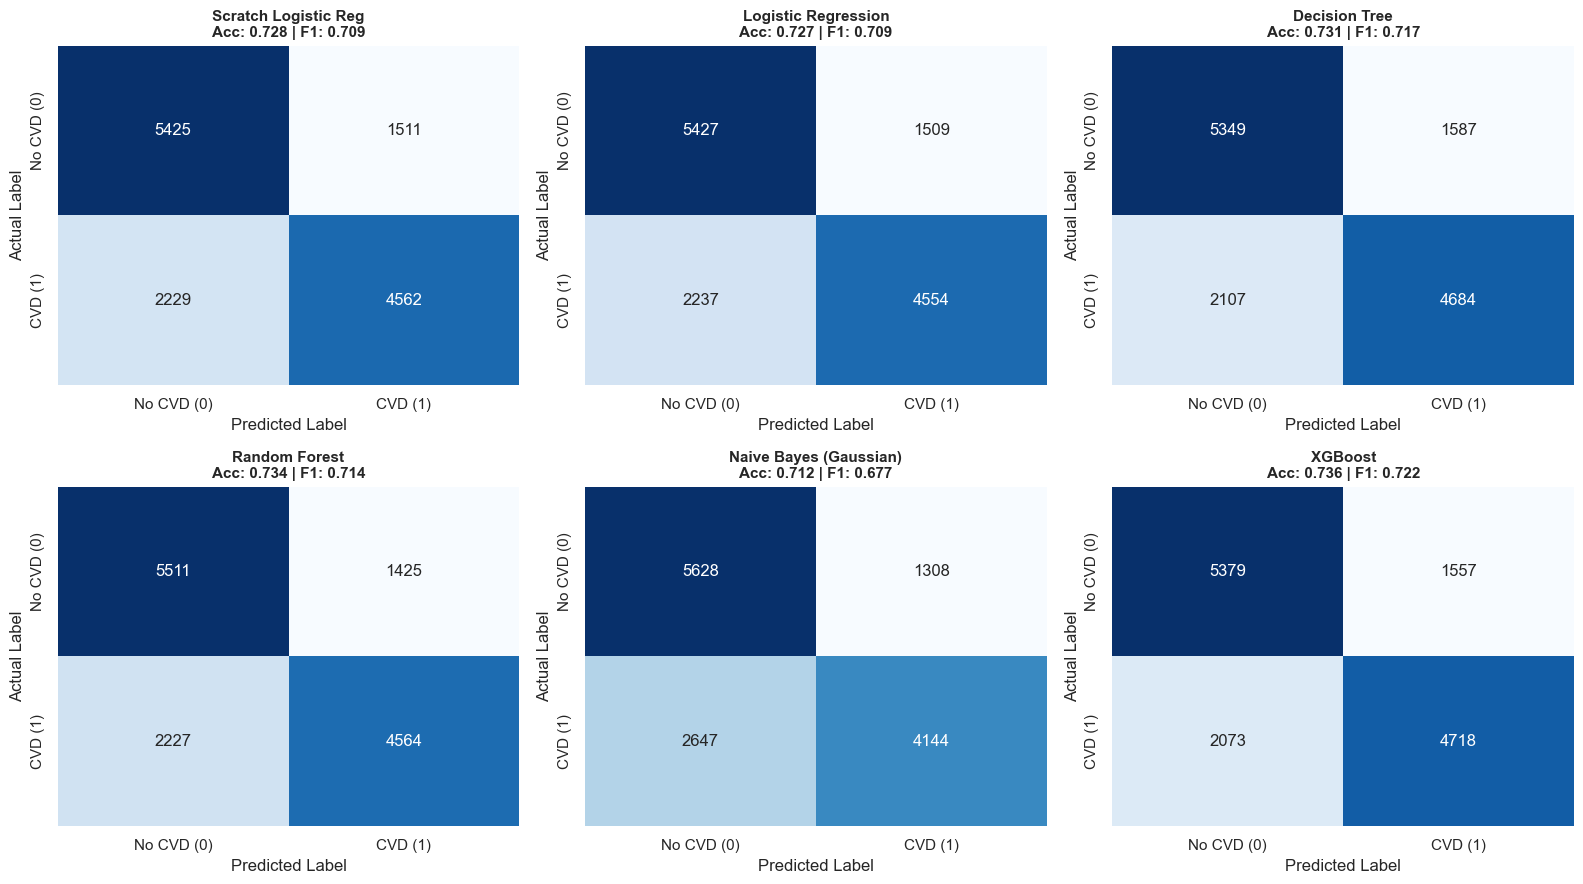

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 9))
models_to_plot = [m for m in baseline_models.keys() if m != 'K-Nearest Neighbors'][:6]

for idx, m_name in enumerate(models_to_plot):
    plt.subplot(2, 3, idx + 1)
    cm = confusion_matrix(y_test, y_preds_dict[m_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No CVD (0)', 'CVD (1)'],
                yticklabels=['No CVD (0)', 'CVD (1)'])
    plt.title(f"{m_name}\nAcc: {accuracy_score(y_test, y_preds_dict[m_name]):.3f} | F1: {f1_score(y_test, y_preds_dict[m_name]):.3f}",
              fontsize=11, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 6.5 ROC Curves Comparison

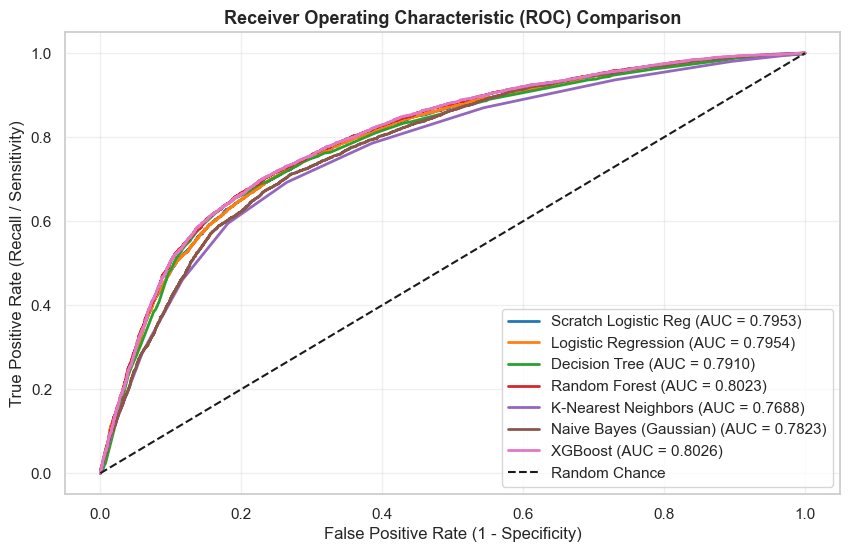

In [32]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 6))
palette = sns.color_palette("tab10", len(baseline_models))

for idx, (m_name, probs) in enumerate(y_probs_dict.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{m_name} (AUC = {score:.4f})", color=palette[idx], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### 6.6 Precision-Recall Curves Comparison

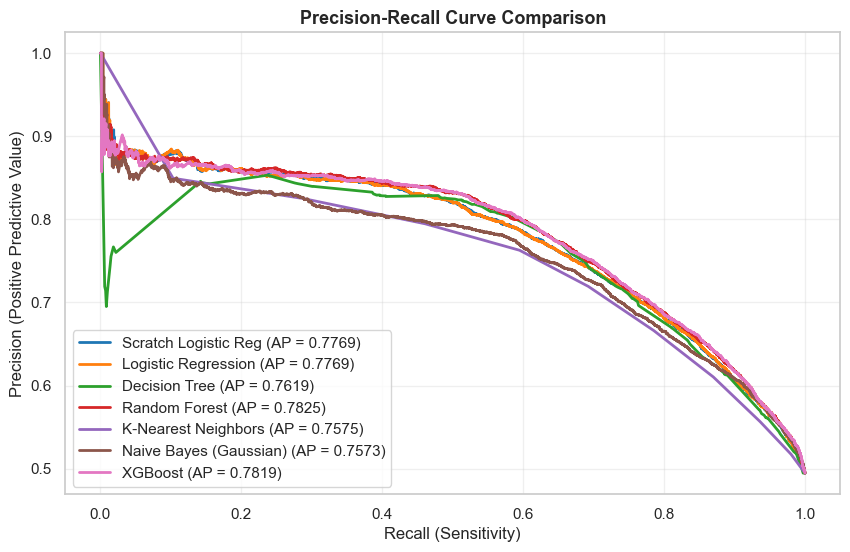

In [33]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(10, 6))

for idx, (m_name, probs) in enumerate(y_probs_dict.items()):
    pr, rc, _ = precision_recall_curve(y_test, probs)
    ap = auc(rc, pr)
    plt.plot(rc, pr, label=f"{m_name} (AP = {ap:.4f})", color=palette[idx], lw=2)

plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title('Precision-Recall Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Overfitting & Underfitting Diagnosis (Week 4 Milestone)
Analyzing learning curves across sample sizes ($10\%$ to $100\%$) to detect generalization gaps.

### 7.1 Learning Curves Computation & Plotting

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encounte

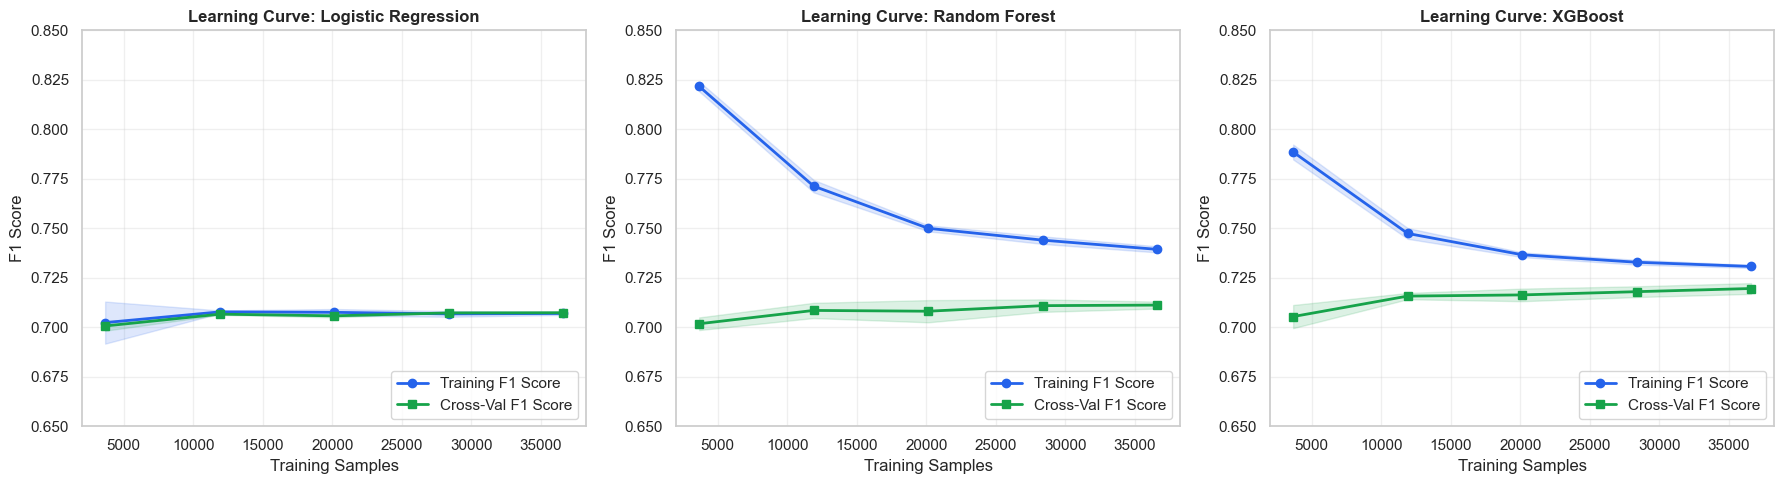

In [34]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lc_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=80, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', max_depth=5, learning_rate=0.08, n_estimators=100, random_state=42, n_jobs=-1)
}

train_sizes_rel = np.linspace(0.1, 1.0, 5)

for idx, (name, model) in enumerate(lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train, train_sizes=train_sizes_rel,
        cv=3, scoring='f1', n_jobs=-1, random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    ax = axes[idx]
    ax.plot(train_sizes, train_mean, 'o-', color='#2563eb', label='Training F1 Score', lw=2)
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#2563eb')
    ax.plot(train_sizes, val_mean, 's-', color='#16a34a', label='Cross-Val F1 Score', lw=2)
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#16a34a')
    
    ax.set_title(f"Learning Curve: {name}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('F1 Score')
    ax.set_ylim([0.65, 0.85])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 5-Fold Stratified Cross-Validation (Week 5 SOP Milestone)
Evaluating model stability and variance across 5 distinct validation folds.

### 8.1 Execute 5-Fold Stratified Cross-Validation

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_split=20, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting (GBDT)': GradientBoostingClassifier(n_estimators=120, max_depth=4, learning_rate=0.08, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', max_depth=5, learning_rate=0.08, n_estimators=120, random_state=42, n_jobs=-1)
}

scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}
cv_results_list = []

for name, model in cv_models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results_list.append({
        'Model': name,
        'CV Accuracy': f"{scores['test_accuracy'].mean()*100:.2f}% ± {scores['test_accuracy'].std()*100:.2f}%",
        'CV Precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        'CV Recall': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        'CV F1-Score': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        'CV ROC-AUC': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        'mean_f1': scores['test_f1'].mean()
    })

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

### 8.2 5-Fold Cross-Validation Stability Table

In [36]:
cv_df = pd.DataFrame(cv_results_list).sort_values(by='mean_f1', ascending=False).drop(columns=['mean_f1'])
display(cv_df)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC
4,Gradient Boosting (GBDT),73.51% ± 0.27%,0.7535 ± 0.0056,0.6903 ± 0.0073,0.7205 ± 0.0031,0.8010 ± 0.0043
6,XGBoost,73.52% ± 0.35%,0.7559 ± 0.0066,0.6865 ± 0.0068,0.7195 ± 0.0035,0.8009 ± 0.0045
1,Decision Tree,72.81% ± 0.46%,0.7440 ± 0.0133,0.6878 ± 0.0204,0.7144 ± 0.0069,0.7901 ± 0.0049
2,Random Forest,73.38% ± 0.28%,0.7647 ± 0.0051,0.6672 ± 0.0076,0.7126 ± 0.0038,0.7995 ± 0.0039
3,Extra Trees,73.06% ± 0.43%,0.7619 ± 0.0074,0.6626 ± 0.0077,0.7087 ± 0.0047,0.7964 ± 0.0044
0,Logistic Regression,72.73% ± 0.29%,0.7539 ± 0.0054,0.6664 ± 0.0076,0.7074 ± 0.0037,0.7901 ± 0.0041
5,AdaBoost,71.71% ± 0.22%,0.7687 ± 0.0044,0.6124 ± 0.0068,0.6817 ± 0.0035,0.7887 ± 0.0043


## 9. Hyperparameter Optimization with GridSearchCV (Week 5 Milestone)
Fine-tuning top-performing models (**XGBoost** and **Random Forest**) to maximize ROC-AUC.

### 9.1 XGBoost Hyperparameter Optimization

In [37]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.08, 0.15],
    'n_estimators': [100, 150],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

print(f"Optimal XGBoost Hyperparameters: {xgb_grid.best_params_}")
print(f"Best 3-Fold ROC-AUC: {xgb_grid.best_score_:.4f}")

Optimal XGBoost Hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
Best 3-Fold ROC-AUC: 0.8012


### 9.2 Random Forest Hyperparameter Optimization

In [38]:
rf_param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [8, 12, 16],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [4, 8]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=3, scoring='roc_auc', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

print(f"Optimal Random Forest Hyperparameters: {rf_grid.best_params_}")
print(f"Best 3-Fold ROC-AUC: {rf_grid.best_score_:.4f}")

Optimal Random Forest Hyperparameters: {'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 150}
Best 3-Fold ROC-AUC: 0.7996


## 10. Advanced Ensemble Modeling (Week 5 Milestone)
Constructing **Soft Voting** and **Stacking** Meta-Models to combine linear and tree learners.

### 10.1 Soft Voting & Stacking Ensemble Fitting

In [39]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[('xgb', best_xgb), ('rf', best_rf), ('lr', log_reg)],
    voting='soft', n_jobs=-1
).fit(X_train_scaled, y_train)

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[('xgb', best_xgb), ('rf', best_rf), ('lr', log_reg)],
    final_estimator=LogisticRegression(), cv=3, n_jobs=-1
).fit(X_train_scaled, y_train)

print("✅ Ensembles successfully trained!")

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/cryptorth/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_

✅ Ensembles successfully trained!


### 10.2 Final Advanced Model Benchmark Table (Hold-Out Test Set)

In [40]:
from sklearn.metrics import brier_score_loss

advanced_models = {
    'Stacking Classifier': stacking_clf,
    'Soft Voting Ensemble': voting_clf,
    'Tuned XGBoost': best_xgb,
    'Gradient Boosting (GBDT)': GradientBoostingClassifier(n_estimators=120, max_depth=4, learning_rate=0.08, random_state=42).fit(X_train_scaled, y_train),
    'Tuned Random Forest': best_rf,
    'Extra Trees': ExtraTreesClassifier(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1).fit(X_train_scaled, y_train)
}

adv_results = []
for name, model in advanced_models.items():
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    
    adv_results.append({
        'Model': name,
        'Test Accuracy (%)': round(accuracy_score(y_test, preds) * 100, 2),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall (Sens)': round(recall_score(y_test, preds), 4),
        'Specificity': round(tn / (tn + fp), 4),
        'F1-Score': round(f1_score(y_test, preds), 4),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 4),
        'Brier Score': round(brier_score_loss(y_test, probs), 4)
    })

adv_df = pd.DataFrame(adv_results).sort_values(by='ROC-AUC', ascending=False)
display(adv_df)

,Model,Test Accuracy (%),Precision,Recall (Sens),Specificity,F1-Score,ROC-AUC,Brier Score
0,Stacking Classifier,73.52,0.7514,0.6944,0.7751,0.7218,0.8037,0.1802
1,Soft Voting Ensemble,73.43,0.7545,0.6863,0.7813,0.7188,0.8034,0.1802
2,Tuned XGBoost,73.44,0.7518,0.6914,0.7765,0.7203,0.8033,0.1801
3,Gradient Boosting (GBDT),73.58,0.7512,0.6968,0.7741,0.7230,0.8027,0.1801
4,Tuned Random Forest,73.40,0.7562,0.6824,0.7846,0.7174,0.8021,0.1806
5,Extra Trees,73.21,0.7624,0.6662,0.7967,0.7110,0.8021,0.1840


### 10.3 Advanced Ensemble ROC Curves

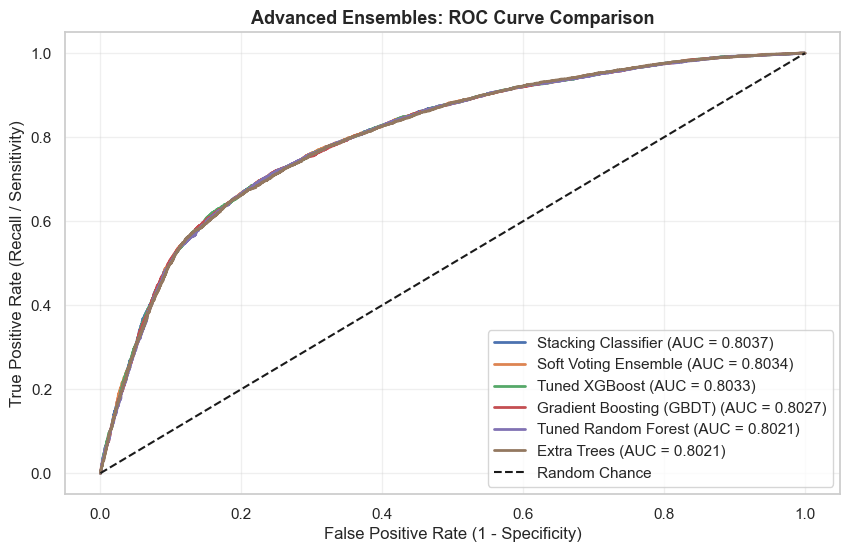

In [41]:
plt.figure(figsize=(10, 6))
palette_adv = sns.color_palette("deep", len(advanced_models))

for idx, (name, model) in enumerate(advanced_models.items()):
    probs = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.4f})", color=palette_adv[idx], lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall / Sensitivity)')
plt.title('Advanced Ensembles: ROC Curve Comparison', fontsize=13, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 11. Feature Importance & Clinical Decision Optimization (Week 5 Milestone)
Quantifying clinical feature contributions and selecting the optimal probability threshold.

### 11.1 Feature Importance: XGBoost (Gain) vs Random Forest (Gini)

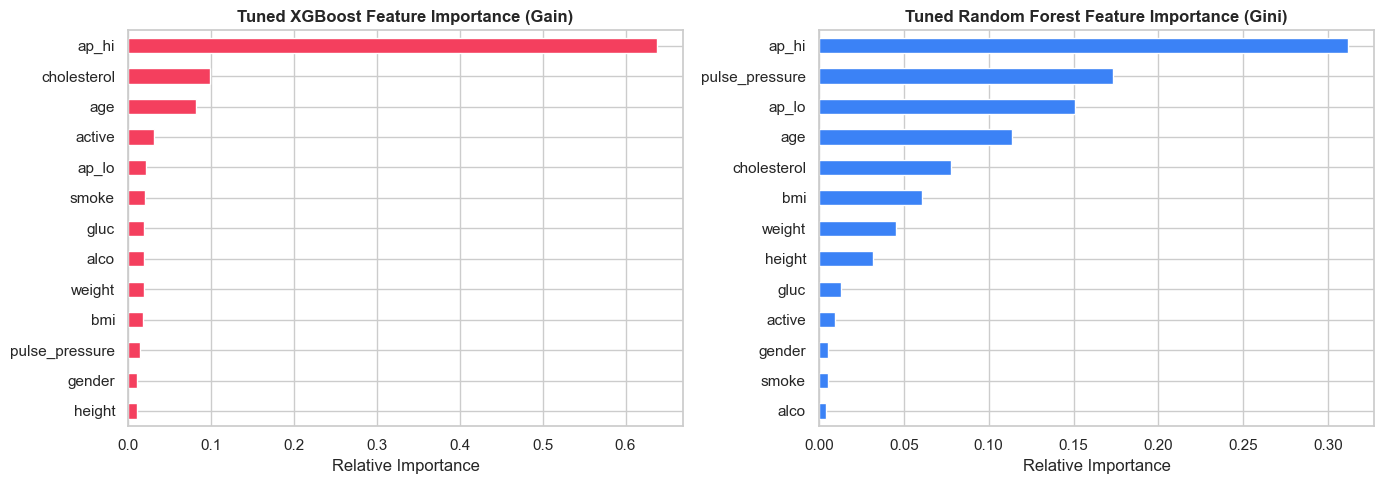

In [42]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
feature_names = continuous_features + categorical_features
pd.Series(best_xgb.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='#f43f5e')
plt.title('Tuned XGBoost Feature Importance (Gain)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance')

plt.subplot(1, 2, 2)
pd.Series(best_rf.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='#3b82f6')
plt.title('Tuned Random Forest Feature Importance (Gini)', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance')

plt.tight_layout()
plt.show()

### 11.2 Clinical Decision Threshold Sweep ($0.10$ to $0.90$)

In [43]:
thresholds = np.linspace(0.1, 0.9, 81)
t_metrics = []
xgb_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]

for t in thresholds:
    t_preds = (xgb_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, t_preds).ravel()
    t_metrics.append({
        'threshold': t,
        'accuracy': accuracy_score(y_test, t_preds),
        'precision': precision_score(y_test, t_preds, zero_division=0),
        'recall': recall_score(y_test, t_preds),
        'f1': f1_score(y_test, t_preds),
        'specificity': tn / (tn + fp)
    })

t_df = pd.DataFrame(t_metrics)
best_f1_idx = t_df['f1'].idxmax()
opt_t = t_df.loc[best_f1_idx, 'threshold']

print(f"Optimal Threshold for F1-Score: {opt_t:.2f}")
print(f"Metrics at Threshold {opt_t:.2f}:")
print(f"  F1-Score:    {t_df.loc[best_f1_idx, 'f1']:.4f}")
print(f"  Recall/Sens: {t_df.loc[best_f1_idx, 'recall']:.4f}")
print(f"  Precision:   {t_df.loc[best_f1_idx, 'precision']:.4f}")

Optimal Threshold for F1-Score: 0.35
Metrics at Threshold 0.35:
  F1-Score:    0.7410
  Recall/Sens: 0.8392
  Precision:   0.6634


### 11.3 Plot Decision Threshold Optimization Curve

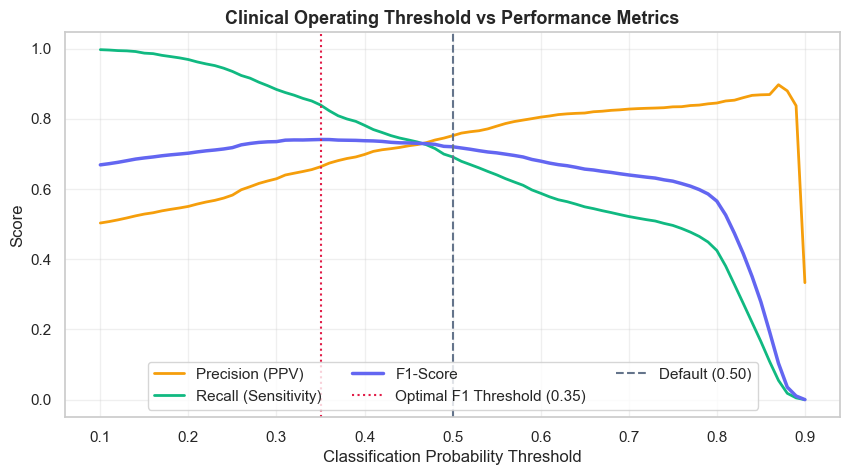

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(t_df['threshold'], t_df['precision'], label='Precision (PPV)', color='#f59e0b', lw=2)
plt.plot(t_df['threshold'], t_df['recall'], label='Recall (Sensitivity)', color='#10b981', lw=2)
plt.plot(t_df['threshold'], t_df['f1'], label='F1-Score', color='#6366f1', lw=2.5)
plt.axvline(opt_t, color='#e11d48', linestyle=':', label=f"Optimal F1 Threshold ({opt_t:.2f})")
plt.axvline(0.50, color='#64748b', linestyle='--', label="Default (0.50)")

plt.xlabel('Classification Probability Threshold')
plt.ylabel('Score')
plt.title('Clinical Operating Threshold vs Performance Metrics', fontsize=13, fontweight='bold')
plt.legend(loc='lower center', ncol=3)
plt.grid(True, alpha=0.3)
plt.show()

## 12. Model Persistence & Deployment Artifacts
Exporting model weights, scaler coefficients, and pickled pipelines for production and frontend integration.

### 12.1 Export Trained Pipeline with Joblib

In [45]:
import joblib

checkpoint_dir = "/Users/cryptorth/Documents/ml/projects"
os.makedirs(checkpoint_dir, exist_ok=True)

joblib.dump(best_xgb, os.path.join(checkpoint_dir, "best_xgboost_model.pkl"))
joblib.dump(preprocessor, os.path.join(checkpoint_dir, "preprocessor_scaler.pkl"))
print("✅ Saved best_xgboost_model.pkl and preprocessor_scaler.pkl successfully!")

✅ Saved best_xgboost_model.pkl and preprocessor_scaler.pkl successfully!
